MARKDOWN

Decision Tree Classification – Airline Customer Satisfaction

This project uses Decision Tree Classification and GridSearchCV to predict airline customer satisfaction. The model is optimized using hyperparameter tuning and evaluated using confusion matrix and F1-score. Feature importance is extracted to provide actionable recommendations for airline management.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score
)

In [ ]:
df = pd.read_csv("Downloads/invistico_airline_new.csv")
df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [ ]:
df.shape

(129880, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

In [ ]:
df.isnull().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

Feature and Target Variables

In [ ]:

X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

In [ ]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print(categorical_cols)
print(numerical_cols)

Index(['Customer Type', 'Type of Travel', 'Class'], dtype='object')
Index(['Age', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

Hyperparameter Tuning using GridSearchCV

In [ ]:
param_grid = {
    "classifier__max_depth": [5, 10, 15],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

In [ ]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_leaf': [1, 2], 'classifier__min_samples_split': [2, 5]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [ ]:
grid_search.best_params_

{'classifier__max_depth': 15,
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 5}

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)

Confusion Matrix

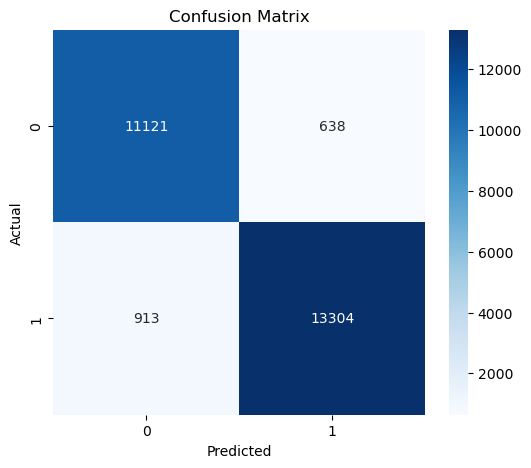

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

dissatisfied       0.92      0.95      0.93     11759
   satisfied       0.95      0.94      0.94     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



In [ ]:
f1 = f1_score(
    y_test,
    y_pred,
    pos_label='satisfied'
)

print("F1-score for Satisfied class:", round(f1,4))

F1-score for Satisfied class: 0.9449


Feature Importance

In [ ]:
feature_names = (
    best_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.named_steps[
        "classifier"
    ].feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
7,num__Inflight entertainment,0.437275
2,num__Seat comfort,0.193047
9,num__Ease of Online booking,0.070501
19,cat__Customer Type_disloyal Customer,0.031529
5,num__Gate location,0.027378
22,cat__Class_Business,0.023366
3,num__Departure/Arrival time convenient,0.020167
20,cat__Type of Travel_Business travel,0.018578
8,num__Online support,0.017390
18,cat__Customer Type_Loyal Customer,0.016736


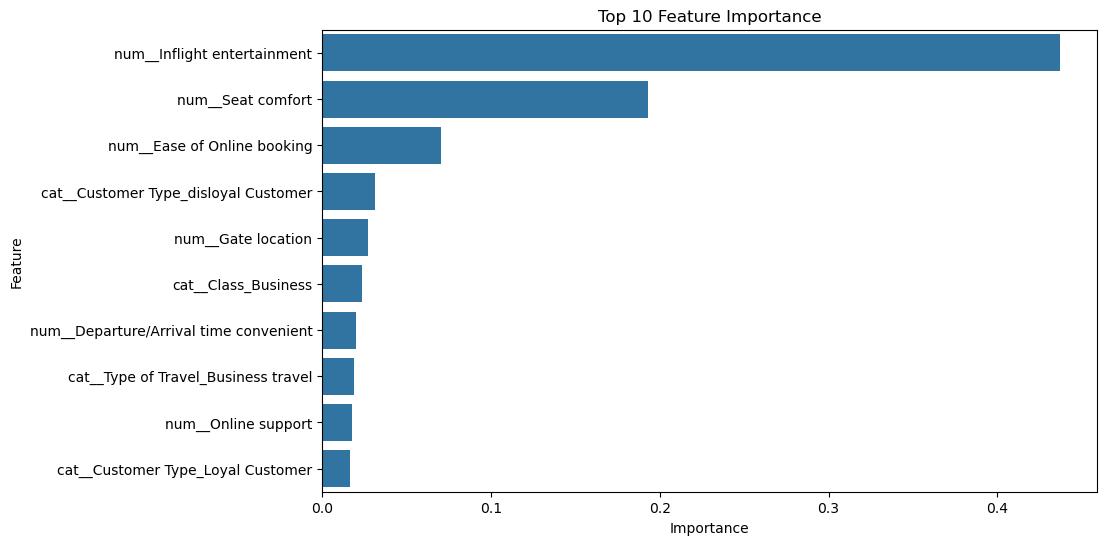

In [ ]:
top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")

plt.show()

Decision Tree Visualization

In [ ]:
tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", tree_model)
    ]
)

tree_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


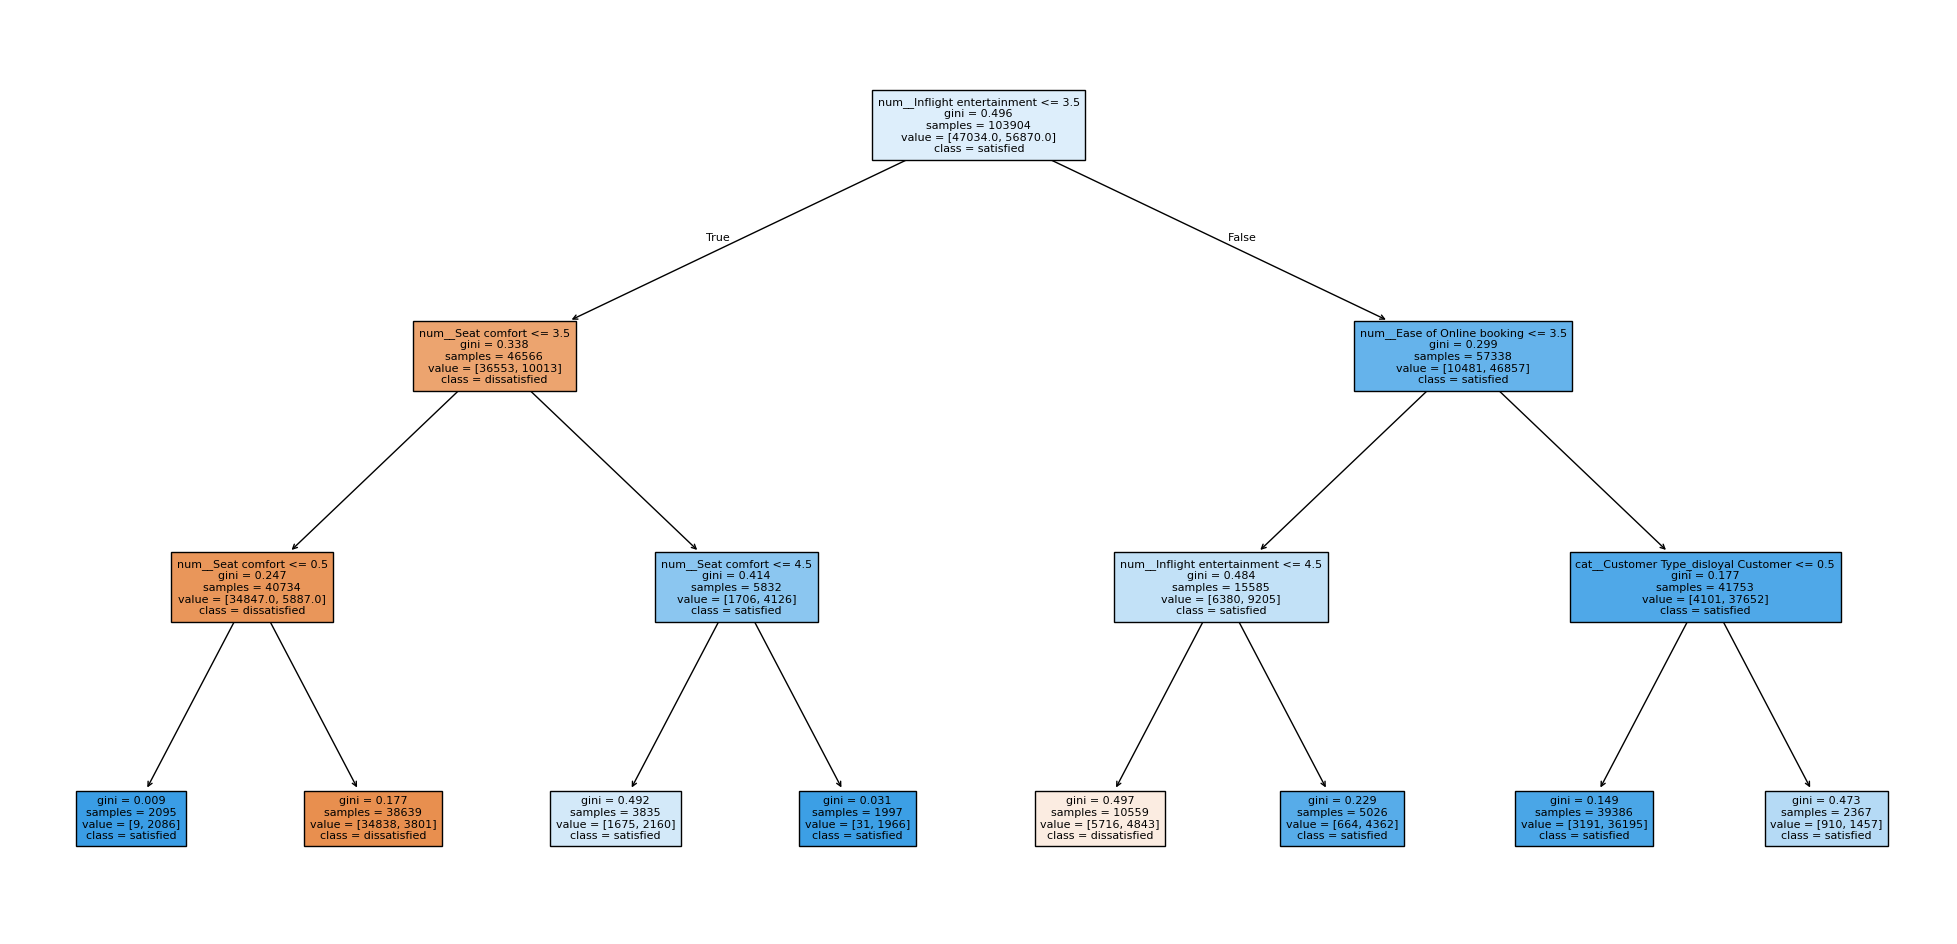

In [ ]:
clf = tree_pipeline.named_steps["classifier"]

feature_names = (
    tree_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

plt.figure(figsize=(25,12))

plot_tree(
    clf,
    feature_names=feature_names,
    class_names=clf.classes_,
    filled=True,
    fontsize=8
)

plt.show()

Business Comparison: Decision Tree vs Logistic Regression


| Decision Tree                        | Logistic Regression          |
| ------------------------------------ | ---------------------------- |
| Highly interpretable                 | Moderate interpretability    |
| Handles nonlinear relationships      | Assumes linearity            |
| Easy to explain to managers          | Strong probability estimates |
| Can overfit without tuning           | More stable                  |
| Excellent for business actionability | Excellent baseline model     |
